# Cityscapes: что лежит на диске и что уходит в модель

Ноутбучный вариант `tests/segmentation_visualization_test.py`.

Для случайных (или заданных) картинок показывает четыре панели:

1. оригинал с диска;
2. оригинал с наложенной GT-маской;
3. вход модели — после `data/transform/<pipeline>`, денормализованный обратно для показа;
4. вход модели с маской, прошедшей ровно те же геометрические преобразования.

**Зачем.** В сегментации аугментации обязаны двигать картинку и маску вместе.
Рассинхрон (маску проресайзили билинейно и получили несуществующие классы, флип
применился только к картинке, паддинг после кропа залит нулём — то есть классом
`road` — вместо `ignore_index`) не виден ни в лоссе, ни в mIoU, но виден здесь глазами.

Ноутбук ищет корень репозитория сам, поэтому запускается и из `notebooks/`, и из корня.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "configs").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "configs").is_dir():
    raise RuntimeError(
        "Не найден корень репозитория (каталог configs/). "
        "Запусти ноутбук изнутри репозитория Juicer-for-models."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Корень репозитория:", REPO_ROOT)

Корень репозитория: /home/m.obukhov/Juicer-for-models


In [9]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from matplotlib.patches import Patch
from omegaconf import OmegaConf
from PIL import Image

from src.data.datasets import CITYSCAPES_SEGMENTATION_CLASSES, CityscapesSegmentation

## Параметры

Единственная ячейка, которую нужно править.

In [ ]:
COUNT = 3             # сколько картинок показать
SPLIT = "train"       # "train" | "val"
PIPELINE = None       # "train" | "eval"; None -> совпадает со SPLIT
SEED = 0              # фиксирует и выбор картинок, и аугментации; None -> каждый запуск новый
INDICES = None        # напр. [17, 42] -> показать эти индексы вместо случайных (COUNT игнорируется)
ROOT = None           # None -> путь из конфига (data/raw/cityscapes)
ALPHA = 0.45          # прозрачность маски поверх картинки, 0..1
LEGEND = "present"    # "present" (только встретившиеся классы) | "all" | "none"
STATS_COUNT = 100     # по скольким маскам считать распределение классов (0 -> не считать)
SAVE_PATH = None      # напр. REPO_ROOT / "outputs" / "dataset_preview.png"

# Override'ы Hydra в том же виде, что и в CLI:
#   ["data.dataset.crop_size=[768,768]", "data.dataset.scale_range=[0.75,1.25]"]
EXTRA_OVERRIDES: list[str] = []

# Группы конфигов, без которых сегментационный пайплайн не соберётся.
DEFAULT_OVERRIDES = [
    "data/dataset=cityscapes_seg",
    "data/transform/train=cityscapes_seg_strong_transform",
    "data/transform/eval=cityscapes_seg_strong_transform",
    "task_type=segmentation",
]

## Палитра и вспомогательные функции

Цвета — официальная палитра Cityscapes, чтобы картинки отсюда можно было
сравнивать с публикациями. Void-пиксели (`ignore_index`) рисуются чёрным
и **не** накладываются на изображение: так сразу видно, где разметки нет.

In [25]:
CITYSCAPES_PALETTE = (
    (128, 64, 128),   # road
    (244, 35, 232),   # sidewalk
    (70, 70, 70),     # building
    (102, 102, 156),  # wall
    (190, 153, 153),  # fence
    (153, 153, 153),  # pole
    (250, 170, 30),   # traffic light
    (220, 220, 0),    # traffic sign
    (107, 142, 35),   # vegetation
    (152, 251, 152),  # terrain
    (70, 130, 180),   # sky
    (220, 20, 60),    # person
    (255, 0, 0),      # rider
    (0, 0, 142),      # car
    (0, 0, 70),       # truck
    (0, 60, 100),     # bus
    (0, 80, 100),     # train
    (0, 0, 230),      # motorcycle
    (119, 11, 32),    # bicycle
)

IGNORE_COLOR = (0, 0, 0)


def build_color_lut() -> np.ndarray:
    """LUT на все 256 значений uint8.

    Всё, что не train_id 0..18 (включая ignore_index=255), получает IGNORE_COLOR:
    маска не обязана содержать только валидные классы, и падать здесь не на чем.
    """
    lut = np.full((256, 3), IGNORE_COLOR, dtype=np.uint8)
    for train_id, color in enumerate(CITYSCAPES_PALETTE):
        lut[train_id] = color
    return lut


def colorize_mask(mask: torch.Tensor, lut: np.ndarray) -> np.ndarray:
    """Маска [H, W] с train_id -> RGB [H, W, 3]."""
    values = mask.detach().cpu().numpy()
    if values.dtype != np.uint8:
        values = np.clip(values, 0, 255).astype(np.uint8)
    return lut[values]


def to_uint8_image(image: torch.Tensor, mean=None, std=None) -> np.ndarray:
    """Тензор [C, H, W] -> картинка uint8. mean/std заданы — сначала денормализация."""
    image = image.detach().float().cpu()

    if mean is not None and std is not None:
        mean_tensor = torch.tensor(mean).view(-1, 1, 1)
        std_tensor = torch.tensor(std).view(-1, 1, 1)
        image = image * std_tensor + mean_tensor

    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return (image * 255).round().astype(np.uint8)


def blend(
    image: np.ndarray,
    color_mask: np.ndarray,
    alpha: float = 0.45,
    valid: np.ndarray | None = None,
) -> np.ndarray:
    """Полупрозрачная маска поверх картинки.

    valid — булева карта [H, W]: где False, пиксель остаётся исходным.
    """
    mixed = (1 - alpha) * image.astype(np.float32) + alpha * color_mask.astype(np.float32)
    mixed = mixed.round().clip(0, 255).astype(np.uint8)

    if valid is not None:
        mixed = np.where(valid[..., None], mixed, image)

    return mixed


def class_name(value: int, ignore_index: int) -> str:
    if value == ignore_index:
        return "IGNORE"
    if 0 <= value < len(CITYSCAPES_SEGMENTATION_CLASSES):
        return CITYSCAPES_SEGMENTATION_CLASSES[value]
    return f"UNKNOWN({value})"


def mask_class_shares(mask: torch.Tensor) -> dict[int, float]:
    """{train_id: доля пикселей в [0, 1]}, по убыванию доли."""
    total = mask.numel()
    values, counts = torch.unique(mask, return_counts=True)
    pairs = sorted(zip(values.tolist(), counts.tolist()), key=lambda pair: -pair[1])
    return {value: count / total for value, count in pairs}


def describe_mask(mask: torch.Tensor, ignore_index: int) -> str:
    return " | ".join(
        f"{class_name(value, ignore_index)} {100 * share:.1f}%"
        for value, share in mask_class_shares(mask).items()
    )


def add_class_legend(figure, train_ids, ignore_index: int, show_ignore: bool = True) -> None:
    """Подпись цветов под фигурой: без неё цветная маска нечитаема."""
    handles = [
        Patch(
            facecolor=np.array(CITYSCAPES_PALETTE[train_id]) / 255,
            edgecolor="0.6",
            label=CITYSCAPES_SEGMENTATION_CLASSES[train_id],
        )
        for train_id in train_ids
        if 0 <= train_id < len(CITYSCAPES_PALETTE)
    ]

    if show_ignore:
        handles.append(
            Patch(
                facecolor=np.array(IGNORE_COLOR) / 255,
                edgecolor="0.6",
                label=f"IGNORE ({ignore_index}), не наложен",
            )
        )

    if handles:
        figure.legend(
            handles=handles,
            loc="lower center",
            ncol=min(7, len(handles)),
            fontsize=8,
            frameon=False,
        )


LUT = build_color_lut()

## Конфиг

`initialize_config_dir` вместо `initialize`: в ноутбуке нет файла-вызывателя,
относительно которого Hydra ищет `configs/`. `GlobalHydra.clear()` перед этим —
чтобы ячейку можно было перезапускать, не перезапуская ядро.

In [26]:
GlobalHydra.instance().clear()
with initialize_config_dir(version_base="1.3", config_dir=str(REPO_ROOT / "configs")):
    cfg = compose(config_name="config", overrides=DEFAULT_OVERRIDES + EXTRA_OVERRIDES)

PIPELINE_NAME = PIPELINE or ("train" if SPLIT == "train" else "eval")

MEAN = list(cfg.data.dataset.normalize.mean)
STD = list(cfg.data.dataset.normalize.std)
IGNORE_INDEX = int(cfg.data.dataset.ignore_index)
NUM_CLASSES = int(cfg.data.dataset.num_classes)

DATA_ROOT = Path(ROOT) if ROOT is not None else Path(cfg.data.dataset.build.root)
if not DATA_ROOT.is_absolute():
    DATA_ROOT = REPO_ROOT / DATA_ROOT

print("Датасет:", DATA_ROOT)
print(f"split={SPLIT}, трансформ={PIPELINE_NAME}, классов={NUM_CLASSES}, ignore_index={IGNORE_INDEX}")
print()
print(OmegaConf.to_yaml(cfg.data.transform[PIPELINE_NAME]))

MissingConfigException: In 'config': Could not find 'data/transform/eval/cityscapes_seg_strong_transform'

Available options in 'data/transform/eval':
	base_cityscapes_transform
	base_transform
	cityscapes_seg_transform
	imagenet_transform
	tinyvit_transform
Config search path:
	provider=hydra, path=pkg://hydra.conf
	provider=main, path=file:///home/m.obukhov/Juicer-for-models/configs
	provider=schema, path=structured://

## Датасеты

Два экземпляра одного и того же датасета: без трансформа (как на диске) и с ним
(как уходит в модель). Сид ставится до создания датасетов: `random` управляет
выбором картинок и геометрией, `torch` — ColorJitter'ом.

In [ ]:
if SEED is not None:
    random.seed(SEED)
    torch.manual_seed(SEED)

raw_dataset = CityscapesSegmentation(root=DATA_ROOT, split=SPLIT, ignore_index=IGNORE_INDEX)
transformed_dataset = CityscapesSegmentation(
    root=DATA_ROOT,
    split=SPLIT,
    transform=instantiate(cfg.data.transform[PIPELINE_NAME]),
    ignore_index=IGNORE_INDEX,
)

if INDICES is not None:
    out_of_range = [index for index in INDICES if not 0 <= index < len(raw_dataset)]
    if out_of_range:
        raise ValueError(f"Индексы вне диапазона 0..{len(raw_dataset) - 1}: {out_of_range}")
    sample_indices = list(INDICES)
else:
    if COUNT <= 0:
        raise ValueError(f"COUNT должен быть положительным, получено {COUNT}")
    sample_indices = random.sample(range(len(raw_dataset)), min(COUNT, len(raw_dataset)))

print(f"В сплите {SPLIT}: {len(raw_dataset)} изображений")
print("Показываем индексы:", sample_indices)

В сплите train: 2975 изображений
Показываем индексы: [1577, 1722, 165]


## Оригинал и вход модели рядом

[1/3] hanover/hanover_000000_052013_leftImg8bit.png  (индекс 1577)
  оригинал:    2048x1024 (WxH)  image torch.float32, mask torch.int64
  вход модели: 1024x512 (WxH)  image torch.float32 [-0.88, 2.64], mask torch.int64
  классы на входе модели: road 91.8% | IGNORE 8.2%

[2/3] krefeld/krefeld_000000_001566_leftImg8bit.png  (индекс 1722)
  оригинал:    2048x1024 (WxH)  image torch.float32, mask torch.int64
  вход модели: 1024x512 (WxH)  image torch.float32 [-2.12, 2.33], mask torch.int64
  классы на входе модели: road 45.7% | building 16.5% | vegetation 15.6% | car 12.6% | IGNORE 8.9% | pole 0.2% | sky 0.2% | bicycle 0.1% | terrain 0.1% | traffic sign 0.0% | traffic light 0.0%

[3/3] aachen/aachen_000165_000019_leftImg8bit.png  (индекс 165)
  оригинал:    2048x1024 (WxH)  image torch.float32, mask torch.int64
  вход модели: 1024x512 (WxH)  image torch.float32 [-2.10, 1.38], mask torch.int64
  классы на входе модели: building 96.0% | pole 2.8% | IGNORE 1.2%



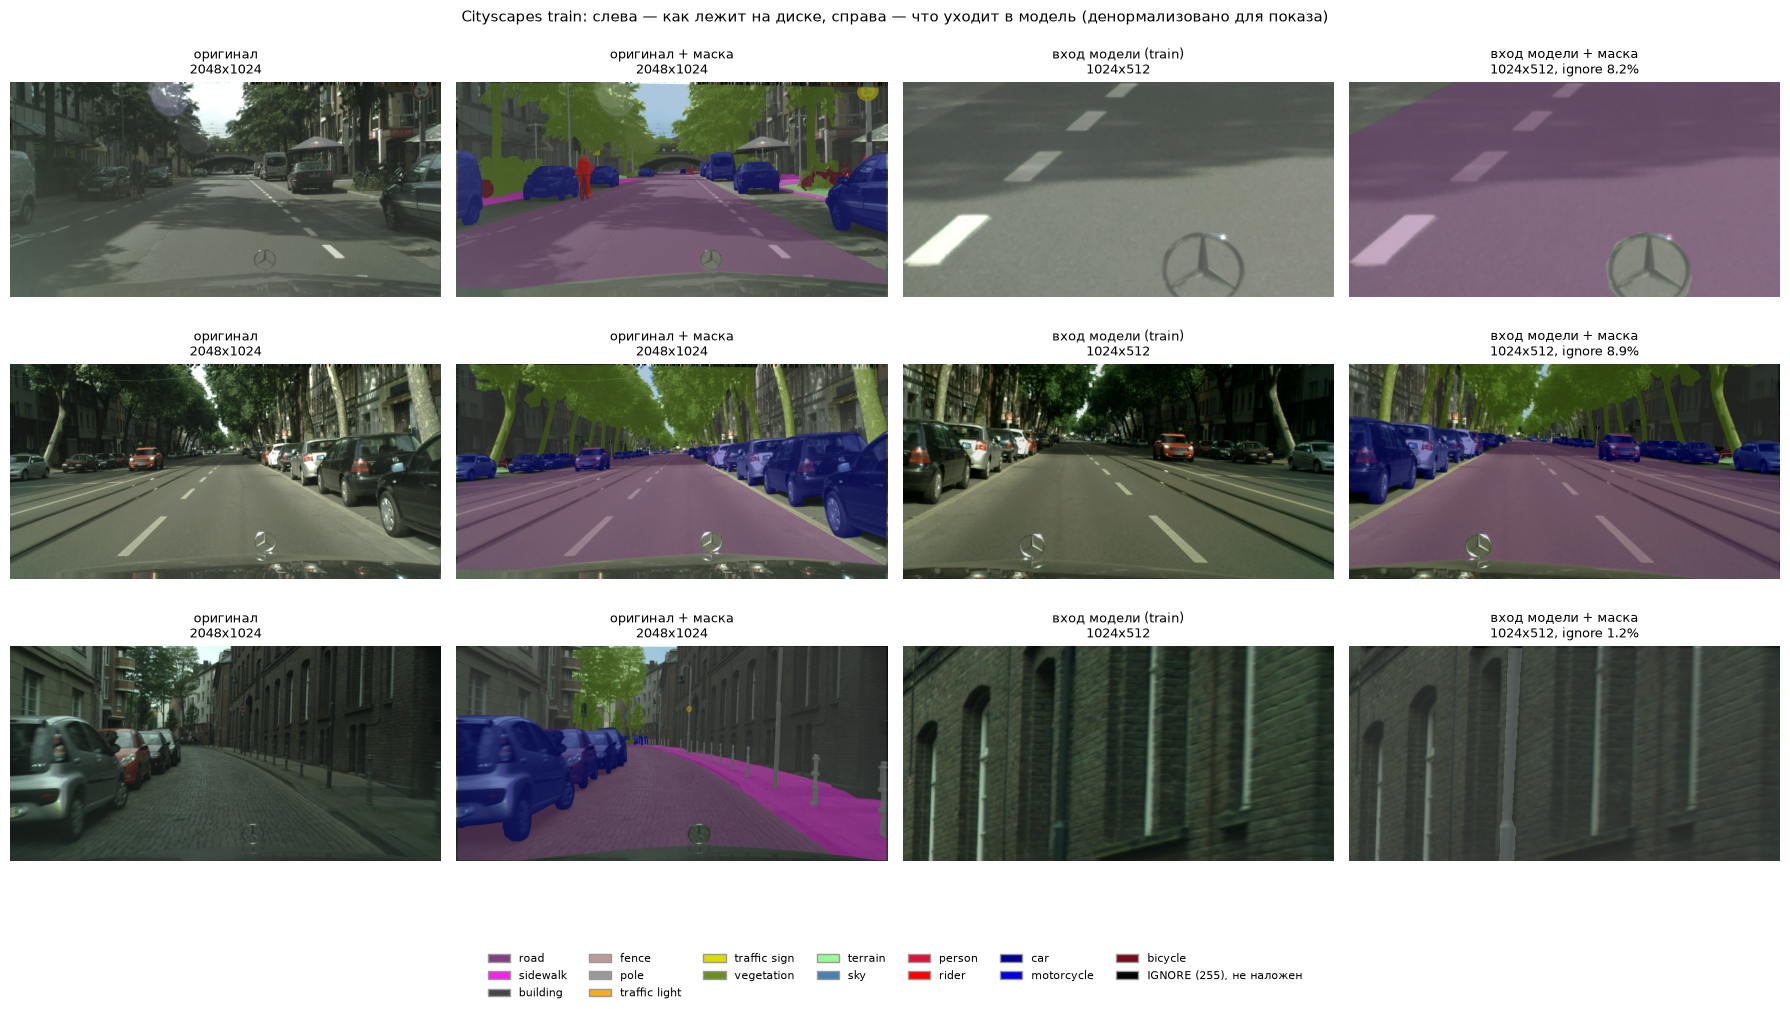

In [13]:
def show_samples(indices, alpha: float = ALPHA, legend: str = LEGEND):
    present_train_ids: set[int] = set()
    rows = []

    for row, index in enumerate(indices):
        raw_image, raw_mask = raw_dataset[index]
        model_image, model_mask = transformed_dataset[index]

        raw_height, raw_width = raw_image.shape[-2:]
        model_height, model_width = model_image.shape[-2:]
        path = raw_dataset.image_paths[index]

        present_train_ids.update(mask_class_shares(raw_mask))
        present_train_ids.update(mask_class_shares(model_mask))

        print(f"[{row + 1}/{len(indices)}] {path.parent.name}/{path.name}  (индекс {index})")
        print(
            f"  оригинал:    {raw_width}x{raw_height} (WxH)  "
            f"image {raw_image.dtype}, mask {raw_mask.dtype}"
        )
        print(
            f"  вход модели: {model_width}x{model_height} (WxH)  image {model_image.dtype} "
            f"[{model_image.min():.2f}, {model_image.max():.2f}], mask {model_mask.dtype}"
        )
        print(f"  классы на входе модели: {describe_mask(model_mask, IGNORE_INDEX)}")
        print()

        raw_display = to_uint8_image(raw_image)
        raw_valid = (raw_mask != IGNORE_INDEX).cpu().numpy()

        model_display = to_uint8_image(model_image, MEAN, STD)
        model_valid = (model_mask != IGNORE_INDEX).cpu().numpy()
        ignore_share = 100 * float((~model_valid).mean())

        panels = (
            (raw_display, f"оригинал\n{raw_width}x{raw_height}"),
            (
                blend(raw_display, colorize_mask(raw_mask, LUT), alpha, raw_valid),
                f"оригинал + маска\n{raw_width}x{raw_height}",
            ),
            (model_display, f"вход модели ({PIPELINE_NAME})\n{model_width}x{model_height}"),
            (
                blend(model_display, colorize_mask(model_mask, LUT), alpha, model_valid),
                f"вход модели + маска\n{model_width}x{model_height}, ignore {ignore_share:.1f}%",
            ),
        )

        rows.append(panels)

    # Размер фигуры — по реальным пропорциям панелей, а не фиксированной высотой
    # строки: при квадратном crop_size строки иначе наезжают заголовками
    # на соседние картинки.
    panel_width = 4.5
    aspect = max(picture.shape[0] / picture.shape[1] for panels in rows for picture, _ in panels)

    figure, axes = plt.subplots(
        len(rows),
        len(rows[0]),
        figsize=(panel_width * len(rows[0]), (panel_width * aspect + 0.9) * len(rows) + 0.7),
        squeeze=False,
    )

    for row, panels in enumerate(rows):
        for column, (picture, title) in enumerate(panels):
            axis = axes[row][column]
            axis.imshow(picture)
            axis.set_title(title, fontsize=9)
            axis.axis("off")

    figure.suptitle(
        f"Cityscapes {SPLIT}: слева — как лежит на диске, "
        f"справа — что уходит в модель (денормализовано для показа)",
        fontsize=11,
    )

    if legend == "none":
        figure.tight_layout()
    else:
        train_ids = (
            list(range(len(CITYSCAPES_SEGMENTATION_CLASSES)))
            if legend == "all"
            else sorted(train_id for train_id in present_train_ids if train_id != IGNORE_INDEX)
        )
        add_class_legend(figure, train_ids, IGNORE_INDEX)
        # Место под легенду резервируется вручную: tight_layout про figure.legend не знает.
        figure.tight_layout(rect=(0, 0.06 + 0.01 * (len(train_ids) // 7), 1, 1))

    return figure


figure = show_samples(sample_indices)
plt.show()

## Перезапуск аугментаций на тех же картинках

Полезно, когда смотришь именно на train-пайплайн: одна и та же картинка каждый
раз даёт новый масштаб, кроп и цвет. Прогони ячейку несколько раз подряд —
если маска хоть раз «поедет» относительно картинки, аугментации сломаны.

[1/3] hanover/hanover_000000_052013_leftImg8bit.png  (индекс 1577)
  оригинал:    2048x1024 (WxH)  image torch.float32, mask torch.int64
  вход модели: 1024x512 (WxH)  image torch.float32 [-1.55, 0.69], mask torch.int64
  классы на входе модели: vegetation 60.3% | sky 14.9% | building 12.4% | IGNORE 8.8% | pole 2.2% | rider 0.9% | traffic sign 0.3% | person 0.1% | car 0.1%

[2/3] krefeld/krefeld_000000_001566_leftImg8bit.png  (индекс 1722)
  оригинал:    2048x1024 (WxH)  image torch.float32, mask torch.int64
  вход модели: 1024x512 (WxH)  image torch.float32 [-2.12, 2.64], mask torch.int64
  классы на входе модели: building 44.5% | car 42.3% | vegetation 10.7% | IGNORE 1.9% | pole 0.7%

[3/3] aachen/aachen_000165_000019_leftImg8bit.png  (индекс 165)
  оригинал:    2048x1024 (WxH)  image torch.float32, mask torch.int64
  вход модели: 1024x512 (WxH)  image torch.float32 [-1.60, 0.37], mask torch.int64
  классы на входе модели: building 59.4% | sidewalk 19.7% | road 15.8% | pole 5.0% | tr

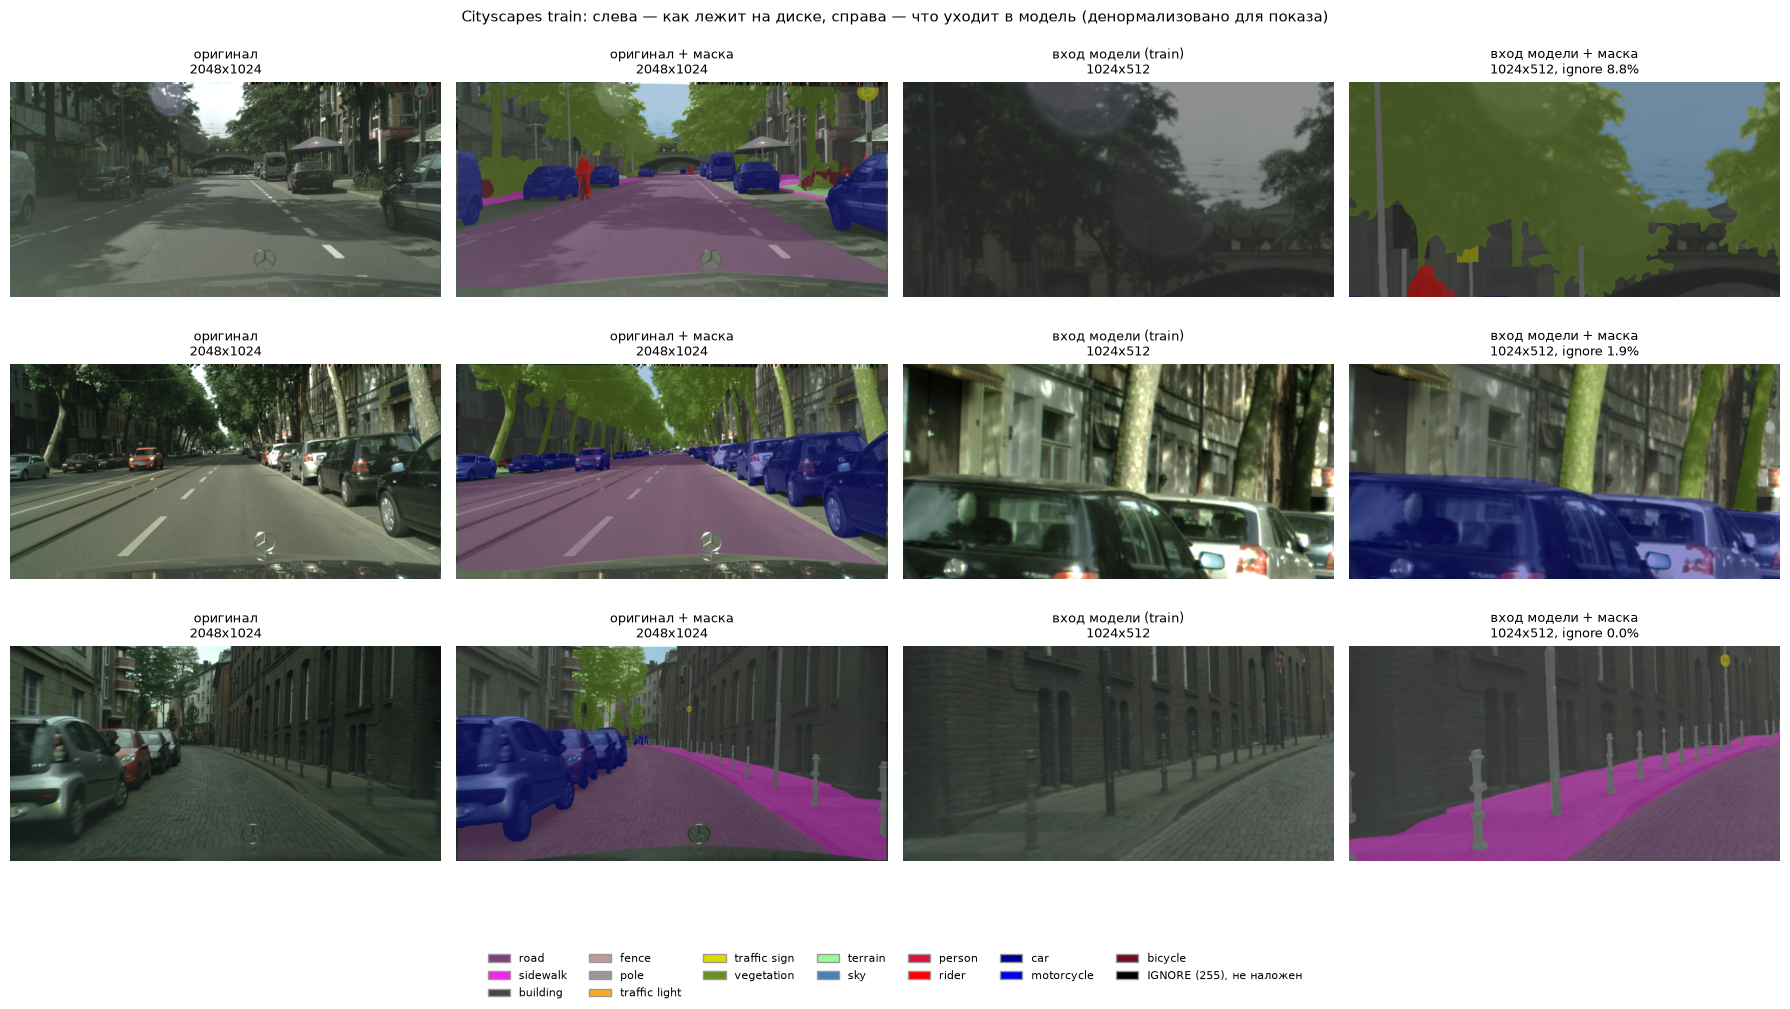

In [14]:
# Сид не ставится намеренно: каждый запуск ячейки — новая случайная аугментация.
figure = show_samples(sample_indices)
plt.show()

## Распределение классов

Cityscapes сильно несбалансирован: `road`, `building` и `vegetation` занимают
подавляющую часть пикселей, а `motorcycle`, `train` и `rider` — доли процента.
Это прямо объясняет разрыв между `pixel_acc` и `mIoU`: точность по пикселям
почти целиком определяют три класса, mIoU усредняет по классам и его тянут вниз
редкие. Считается по маскам напрямую (картинки не читаются) — быстро.

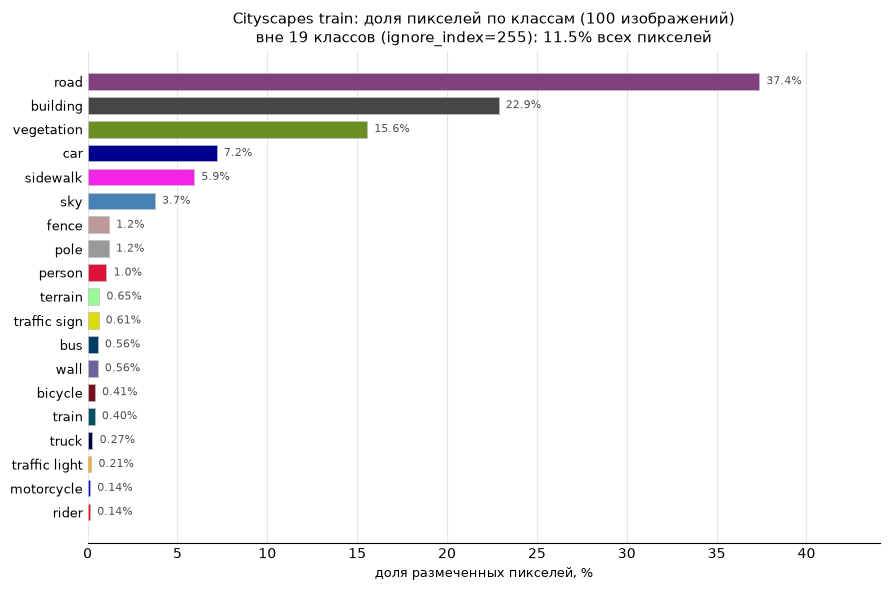

класс            доля, %        пикселей
road              37.365      69,384,200
building          22.866      42,459,372
vegetation        15.555      28,884,412
car                7.180      13,332,298
sidewalk           5.930      11,010,834
sky                3.741       6,947,101
fence              1.191       2,211,728
pole               1.181       2,193,461
person             1.046       1,942,600
terrain            0.650       1,207,652
traffic sign       0.609       1,130,051
bus                0.565       1,048,601
wall               0.561       1,041,315
bicycle            0.409         760,271
train              0.397         736,271
truck              0.273         506,794
traffic light      0.206         383,126
motorcycle         0.138         256,959
rider              0.137         254,278


In [9]:
def collect_class_counts(dataset, indices) -> np.ndarray:
    """Гистограмма train_id по 256 корзинам, накопленная по маскам indices."""
    counts = np.zeros(256, dtype=np.int64)

    for index in indices:
        raw_mask = np.array(Image.open(dataset.mask_paths[index]))
        train_ids = dataset.label_id_to_train_id[raw_mask]
        counts += np.bincount(train_ids.reshape(-1), minlength=256)

    return counts


if STATS_COUNT > 0:
    stats_indices = random.sample(range(len(raw_dataset)), min(STATS_COUNT, len(raw_dataset)))
    class_counts = collect_class_counts(raw_dataset, stats_indices)

    valid_counts = class_counts[:NUM_CLASSES]
    valid_total = valid_counts.sum()
    ignore_share = 100 * class_counts[IGNORE_INDEX] / class_counts.sum()
    shares = 100 * valid_counts / max(valid_total, 1)

    order = np.argsort(shares)  # снизу вверх: barh рисует первый элемент внизу
    positions = np.arange(NUM_CLASSES)

    figure, axis = plt.subplots(figsize=(9, 6))
    axis.barh(
        positions,
        shares[order],
        height=0.7,
        color=[np.array(CITYSCAPES_PALETTE[train_id]) / 255 for train_id in order],
        edgecolor="0.75",
        linewidth=0.5,
    )

    for position, share in zip(positions, shares[order]):
        axis.text(
            share + 0.4,
            position,
            f"{share:.2f}%" if share < 1 else f"{share:.1f}%",
            va="center",
            fontsize=8,
            color="#52514e",
        )

    axis.set_yticks(positions)
    axis.set_yticklabels([CITYSCAPES_SEGMENTATION_CLASSES[train_id] for train_id in order], fontsize=9)
    axis.set_xlabel("доля размеченных пикселей, %", fontsize=9)
    axis.set_xlim(0, float(shares.max()) * 1.18)
    axis.set_title(
        f"Cityscapes {SPLIT}: доля пикселей по классам ({len(stats_indices)} изображений)\n"
        f"вне 19 классов (ignore_index={IGNORE_INDEX}): {ignore_share:.1f}% всех пикселей",
        fontsize=11,
    )
    axis.grid(axis="x", color="0.9", linewidth=0.8)
    axis.set_axisbelow(True)
    for side in ("top", "right", "left"):
        axis.spines[side].set_visible(False)
    axis.tick_params(length=0)

    figure.tight_layout()
    plt.show()

    print(f"{'класс':<14}{'доля, %':>10}{'пикселей':>16}")
    for train_id in np.argsort(-shares):
        print(
            f"{CITYSCAPES_SEGMENTATION_CLASSES[train_id]:<14}"
            f"{shares[train_id]:>10.3f}{valid_counts[train_id]:>16,}"
        )
else:
    print("STATS_COUNT = 0 — статистика классов пропущена")

## Сохранение

`SAVE_PATH = None` — ничего не пишется на диск.

In [10]:
if SAVE_PATH is not None:
    save_path = Path(SAVE_PATH)
    if not save_path.is_absolute():
        save_path = REPO_ROOT / save_path

    save_path.parent.mkdir(parents=True, exist_ok=True)
    figure = show_samples(sample_indices)
    figure.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.close(figure)
    print("Сохранено:", save_path)
else:
    print("SAVE_PATH = None — файл не сохранялся")

SAVE_PATH = None — файл не сохранялся
